# Simple model training

Let's train simple ML models with our data in order to develop a robust model capable of accurately predicting SWF.

### Library loading

In [3]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
import optuna
import xgboost as xgb
import json

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)

### Data setup

We'll train the models with the previous merged datasets.

In [34]:
df = pd.read_parquet("data/windsat_2017")

In [4]:
# drop rows where target is zero and make a copy
initial_count = len(df)
df = df[df['fwns'] != 0].copy()
removed = initial_count - len(df)
print(f"Removed {removed/initial_count*100:.2f}% of {initial_count} rows with fwns == 0")

# box-cox transform (requires strictly positive values)
df['fwns'], fwns_lambda = stats.boxcox(df['fwns'])
print(f"Applied Box‑Cox transform to fwns (lambda={fwns_lambda:.4f})")

# assume all columns except the target are features
feature_cols = df.columns.drop('fwns')
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])
print("Features scaled using StandardScaler")

Removed 32.21% of 13225757 rows with fwns == 0
Applied Box‑Cox transform to fwns (lambda=0.1394)
Features scaled using StandardScaler


In [36]:
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

y = df['fwns']

## TEST

### No changes

In [19]:
# -------- FULL SET --------
X_full_train = df.drop(columns=["fwns"]).loc[train_idx]
X_full_test  = df.drop(columns=["fwns"]).loc[test_idx]
y_full_train = y.loc[train_idx]
y_full_test  = y.loc[test_idx]

In [20]:
results_full = train_and_evaluate_models_list(X_full_train, y_full_train, X_full_test, y_full_test, models)

table_full = format_results_table(results_full)

display(table_full)

,MAE_train,MSE_train,R²_train,MAE_test,MSE_test,R²_test,Tiempo
LinearRegression,0.016981,0.000737,0.864628,0.017008,0.000743,0.863913,7.9165
XGBoost,0.012139,0.000390,0.928330,0.012527,0.000435,0.920371,20.5138


### Scaled

In [21]:
# assume all columns except the target are features
feature_cols = df.columns.drop('fwns')
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])
print("Features scaled using StandardScaler")

Features scaled using StandardScaler


In [22]:
# -------- FULL SET --------
X_full_train = df.drop(columns=["fwns"]).loc[train_idx]
X_full_test  = df.drop(columns=["fwns"]).loc[test_idx]
y_full_train = y.loc[train_idx]
y_full_test  = y.loc[test_idx]

In [23]:
results_full = train_and_evaluate_models_list(X_full_train, y_full_train, X_full_test, y_full_test, models)

table_full = format_results_table(results_full)

display(table_full)

,MAE_train,MSE_train,R²_train,MAE_test,MSE_test,R²_test,Tiempo
LinearRegression,0.016981,0.000737,0.864628,0.017008,0.000743,0.863913,8.4672
XGBoost,0.012108,0.000389,0.928476,0.012497,0.000434,0.920537,20.5056


### No zeroes

In [28]:
# drop rows where target is zero and make a copy
initial_count = len(df)
df = df[df['fwns'] != 0].copy()
removed = initial_count - len(df)
print(f"Removed {removed/initial_count*100:.2f}% of {initial_count} rows with fwns == 0")

Removed 0.00% of 8965273 rows with fwns == 0


In [29]:
# -------- FULL SET --------
X_full_train = df.drop(columns=["fwns"]).loc[train_idx]
X_full_test  = df.drop(columns=["fwns"]).loc[test_idx]
y_full_train = y.loc[train_idx]
y_full_test  = y.loc[test_idx]

In [30]:
results_full = train_and_evaluate_models_list(X_full_train, y_full_train, X_full_test, y_full_test, models)

table_full = format_results_table(results_full)

display(table_full)

,MAE_train,MSE_train,R²_train,MAE_test,MSE_test,R²_test,Tiempo
LinearRegression,0.020008,0.000949,0.860923,0.019991,0.000948,0.860731,5.6292
XGBoost,0.015027,0.000533,0.921890,0.015588,0.000597,0.912276,17.9453


### No zeroes scaled

In [31]:
# drop rows where target is zero and make a copy
initial_count = len(df)
df = df[df['fwns'] != 0].copy()
removed = initial_count - len(df)
print(f"Removed {removed/initial_count*100:.2f}% of {initial_count} rows with fwns == 0")

# assume all columns except the target are features
feature_cols = df.columns.drop('fwns')
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])
print("Features scaled using StandardScaler")

Removed 0.00% of 8965273 rows with fwns == 0
Features scaled using StandardScaler


In [32]:
# -------- FULL SET --------
X_full_train = df.drop(columns=["fwns"]).loc[train_idx]
X_full_test  = df.drop(columns=["fwns"]).loc[test_idx]
y_full_train = y.loc[train_idx]
y_full_test  = y.loc[test_idx]

In [33]:
results_full = train_and_evaluate_models_list(X_full_train, y_full_train, X_full_test, y_full_test, models)

table_full = format_results_table(results_full)

display(table_full)

,MAE_train,MSE_train,R²_train,MAE_test,MSE_test,R²_test,Tiempo
LinearRegression,0.020008,0.000949,0.860923,0.019991,0.000948,0.860731,5.3824
XGBoost,0.015073,0.000537,0.921365,0.015629,0.000600,0.911781,17.7100


### Scaled target

In [35]:
# drop rows where target is zero and make a copy
initial_count = len(df)
df = df[df['fwns'] != 0].copy()
removed = initial_count - len(df)
print(f"Removed {removed/initial_count*100:.2f}% of {initial_count} rows with fwns == 0")

# box-cox transform (requires strictly positive values)
df['fwns'], fwns_lambda = stats.boxcox(df['fwns'])
print(f"Applied Box‑Cox transform to fwns (lambda={fwns_lambda:.4f})")

# assume all columns except the target are features
# feature_cols = df.columns.drop('fwns')
# scaler = StandardScaler()
# df[feature_cols] = scaler.fit_transform(df[feature_cols])
# print("Features scaled using StandardScaler")

Removed 32.21% of 13225757 rows with fwns == 0
Applied Box‑Cox transform to fwns (lambda=0.1394)


In [37]:
# -------- FULL SET --------
X_full_train = df.drop(columns=["fwns"]).loc[train_idx]
X_full_test  = df.drop(columns=["fwns"]).loc[test_idx]
y_full_train = y.loc[train_idx]
y_full_test  = y.loc[test_idx]

In [38]:
results_full = train_and_evaluate_models_list(X_full_train, y_full_train, X_full_test, y_full_test, models)

table_full = format_results_table(results_full)

display(table_full)

,MAE_train,MSE_train,R²_train,MAE_test,MSE_test,R²_test,Tiempo
LinearRegression,0.319404,0.182624,0.740514,0.319745,0.182844,0.740536,5.4946
XGBoost,0.247368,0.119375,0.830383,0.254688,0.126743,0.820146,19.2550


### Full scale

In [40]:
# # drop rows where target is zero and make a copy
# initial_count = len(df)
# df = df[df['fwns'] != 0].copy()
# removed = initial_count - len(df)
# print(f"Removed {removed/initial_count*100:.2f}% of {initial_count} rows with fwns == 0")

# # box-cox transform (requires strictly positive values)
# df['fwns'], fwns_lambda = stats.boxcox(df['fwns'])
# print(f"Applied Box‑Cox transform to fwns (lambda={fwns_lambda:.4f})")

# assume all columns except the target are features
feature_cols = df.columns.drop('fwns')
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])
print("Features scaled using StandardScaler")

Features scaled using StandardScaler


In [41]:
# -------- FULL SET --------
X_full_train = df.drop(columns=["fwns"]).loc[train_idx]
X_full_test  = df.drop(columns=["fwns"]).loc[test_idx]
y_full_train = y.loc[train_idx]
y_full_test  = y.loc[test_idx]

In [42]:
results_full = train_and_evaluate_models_list(X_full_train, y_full_train, X_full_test, y_full_test, models)

table_full = format_results_table(results_full)

display(table_full)

,MAE_train,MSE_train,R²_train,MAE_test,MSE_test,R²_test,Tiempo
LinearRegression,0.319404,0.182624,0.740514,0.319745,0.182844,0.740536,5.3786
XGBoost,0.247597,0.119591,0.830076,0.254846,0.126864,0.819974,19.3668


## Variable selection

We don't just want to achieve the best posible model for SWF regression, we also need to make sure that we are relying on the main capabilities of the satalite and only using auxiliary variables when needed. For this reason, we'll study the obtained accuracy of some base models using different sets of variables.

In [6]:
models = {
    "LinearRegression": LinearRegression(),
    "XGBoost": XGBRegressor(n_estimators=20, learning_rate=0.1, max_depth=15, verbosity=0, random_state=42, device='gpu'),
}

In [7]:
def train_and_evaluate_models_list(X_train, y_train, X_test, y_test, models):
    results_all = {}

    for name, model in models.items() if isinstance(models, dict) else models:

        start_time = time.time()
        model.fit(X_train, y_train)
        elapsed_time = time.time() - start_time

        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        results = {
            "MAE_train": mean_absolute_error(y_train, y_pred_train),
            "MSE_train": mean_squared_error(y_train, y_pred_train),
            "R²_train": r2_score(y_train, y_pred_train),

            "MAE_test": mean_absolute_error(y_test, y_pred_test),
            "MSE_test": mean_squared_error(y_test, y_pred_test),
            "R²_test": r2_score(y_test, y_pred_test),

            "Tiempo": round(elapsed_time, 4)
        }

        results_all[name] = results
    return results_all

def format_results_table(results_dict, tablefmt="github"):
    df = pd.DataFrame(results_dict).T  # filas=modelos, columnas=métricas
    df = df.round(6)

    return df

### Baseline precision

There exists a physical formula for SWF using top of atmosphere brightness temperature (19H), which is what the CIMR satellites are designed to obtain, assisted with surface temperature. We'll rely on the results of this formula as a baseline in order to properly the coming results.

In [ ]:
print("MAE: ", mean_absolute_error(y, df['fwns_calculated']))
print("MSE: ", mean_squared_error(y, df['fwns_calculated']))
print("R²: ", r2_score(y, df['fwns_calculated']))

MAE:  0.03340902509537092
MSE:  0.002748400523857489


R²:  0.49551178121243


### Necessity of surtep5

Since surtep5 is just an auxiliary variable used in the formula, let's see if it truly improves the model performance.

In [9]:
features_1 = [
    "tbtoa19H",
]

features_2 = [
    "tbtoa19H",
    "surtep_ERA5",
]

In [10]:
# -------- SET 1 --------
X1_train = df.loc[train_idx, features_1]
X1_test  = df.loc[test_idx,  features_1]
y1_train = y.loc[train_idx]
y1_test  = y.loc[test_idx]

# -------- SET 2 --------
X2_train = df.loc[train_idx, features_2]
X2_test  = df.loc[test_idx,  features_2]
y2_train = y.loc[train_idx]
y2_test  = y.loc[test_idx]

In [13]:
results1 = train_and_evaluate_models_list(X1_train, y1_train, X1_test, y1_test, models)
results2 = train_and_evaluate_models_list(X2_train, y2_train, X2_test, y2_test, models)

table1 = format_results_table(results1)
table2 = format_results_table(results2)

print(table1)
print(table2)

                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.456003   0.341913  0.514185  0.456042  0.342110   
XGBoost            0.452396   0.338560  0.518949  0.452383  0.338752   

                   R²_test  Tiempo  
LinearRegression  0.514531  0.1097  
XGBoost           0.519295  1.2912  
                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.423638   0.297358  0.577492  0.423688  0.297591   
XGBoost            0.395701   0.267805  0.619483  0.396967  0.269848   

                   R²_test  Tiempo  
LinearRegression  0.577704  0.1964  
XGBoost           0.617073  6.4945  


In [14]:
results1 = train_and_evaluate_models_list(X1_train, y1_train, X1_test, y1_test, models)
results2 = train_and_evaluate_models_list(X2_train, y2_train, X2_test, y2_test, models)

table1 = format_results_table(results1)
table2 = format_results_table(results2)

print(table1)
print(table2)

                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.034004   0.002372  0.564308  0.034026  0.002382   
XGBoost            0.027695   0.001866  0.657223  0.027731  0.001876   

                   R²_test  Tiempo  
LinearRegression  0.563688  0.1326  
XGBoost           0.656317  8.1156  
                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.029736   0.001956  0.640677  0.029774  0.001966   
XGBoost            0.024629   0.001501  0.724246  0.024720  0.001520   

                   R²_test   Tiempo  
LinearRegression  0.639918   0.1353  
XGBoost           0.721635  12.7186  


### Atmospheric correction

We can correct our tbtoa using atmospheric variables before training. This will hopefully improve the performance of the model. Let's also check if just adding the variables involved in the correction into the training yields better results.

In [15]:
features_3 = [
    "tbboa_de_lannoy19H",
    "surtep_ERA5",
]

features_4 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "surtep_ERA5",
]

features_5 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "tbboa_1st_order19H",
    "tbboa_de_lannoy19H",
    "surtep_ERA5",
]

In [16]:
# -------- SET 3 --------
X3_train = df.loc[train_idx, features_3]
X3_test  = df.loc[test_idx,  features_3]
y3_train = y.loc[train_idx]
y3_test  = y.loc[test_idx]

# -------- SET 4 --------
X4_train = df.loc[train_idx, features_4]
X4_test  = df.loc[test_idx,  features_4]
y4_train = y.loc[train_idx]
y4_test  = y.loc[test_idx]

# -------- SET 5 --------
X5_train = df.loc[train_idx, features_5]
X5_test  = df.loc[test_idx,  features_5]
y5_train = y.loc[train_idx]
y5_test  = y.loc[test_idx]

In [17]:
results3 = train_and_evaluate_models_list(X3_train, y3_train, X3_test, y3_test, models)
results4 = train_and_evaluate_models_list(X4_train, y4_train, X4_test, y4_test, models)
results5 = train_and_evaluate_models_list(X5_train, y5_train, X5_test, y5_test, models)

table3 = format_results_table(results3)
table4 = format_results_table(results4)
table5 = format_results_table(results5)

print(table3)
print(table4)
print(table5)

                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.029596   0.001936  0.644408  0.029634  0.001946   
XGBoost            0.024522   0.001488  0.726721  0.024610  0.001506   

                   R²_test   Tiempo  
LinearRegression  0.643634   0.1366  
XGBoost           0.724183  12.8109  
                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.028856   0.001817  0.666333  0.028900  0.001826   
XGBoost            0.020989   0.001157  0.787584  0.021526  0.001249   

                   R²_test   Tiempo  
LinearRegression  0.665519   0.2940  
XGBoost           0.771178  18.6752  
                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.026528   0.001637  0.699411  0.026566  0.001645   
XGBoost            0.020977   0.001155  0.787955  0.021530  0.001250   

                   R²_test   Tiempo  
LinearRegression  0.698676   0.4267  
XGBoost           0.771086  22.0858  


### Lookup tables

In [18]:
features_6 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "surtep_ERA5",
    "vsm",
    "VOD"
]

features_7 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "surtep_ERA5",
    "ref_land_emis_de_lannoy_K_h",
    "ref_land_emis_de_lannoy_K_v"
]

features_8 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "surtep_ERA5",
    "vsm",
    "VOD",
    "ref_land_emis_de_lannoy_K_h",
    "ref_land_emis_de_lannoy_K_v"
]

In [19]:
# -------- SET 6 --------
X6_train = df.loc[train_idx, features_6]
X6_test  = df.loc[test_idx,  features_6]
y6_train = y.loc[train_idx]
y6_test  = y.loc[test_idx]

# -------- SET 7 --------
X7_train = df.loc[train_idx, features_7]
X7_test  = df.loc[test_idx,  features_7]
y7_train = y.loc[train_idx]
y7_test  = y.loc[test_idx]

# -------- SET 8 --------
X8_train = df.loc[train_idx, features_8]
X8_test  = df.loc[test_idx,  features_8]
y8_train = y.loc[train_idx]
y8_test  = y.loc[test_idx]

In [20]:
results6 = train_and_evaluate_models_list(X6_train, y6_train, X6_test, y6_test, models)
results7 = train_and_evaluate_models_list(X7_train, y7_train, X7_test, y7_test, models)
results8 = train_and_evaluate_models_list(X8_train, y8_train, X8_test, y8_test, models)

table6 = format_results_table(results6)
table7 = format_results_table(results7)
table8 = format_results_table(results8)

print(table6)
print(table7)
print(table8)

                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.022200   0.001100   0.79795  0.022230  0.001107   
XGBoost            0.015288   0.000607   0.88846  0.015894  0.000690   

                   R²_test   Tiempo  
LinearRegression  0.797322   0.4664  
XGBoost           0.873534  21.8281  
                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.021606   0.001127  0.793016  0.021642  0.001134   
XGBoost            0.016175   0.000690  0.873255  0.016633  0.000758   

                   R²_test   Tiempo  
LinearRegression  0.792307   0.9145  
XGBoost           0.861136  19.9636  
                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.020104   0.000979  0.820247  0.020132  0.000984   
XGBoost            0.015294   0.000608  0.888416  0.015896  0.000691   

                   R²_test   Tiempo  
LinearRegression  0.819731   1.2803  
XGBoost           0.873478  23.3605  


### Adding new polarization and frequencies

In [21]:
features_9 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "tbtoa37H",
    "tran37H",
    "tbup37H",
    "tbdw37H",
    "surtep_ERA5",
    "vsm",
    "VOD"
]

features_10 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "tbtoa37H",
    "tran37H",
    "tbup37H",
    "tbdw37H",
    "tbtoa19V",
    "tran19V",
    "tbup19V",
    "tbdw19V",
    "tbtoa37V",
    "tran37V",
    "tbup37V",
    "tbdw37V",
    "surtep_ERA5",
    "vsm",
    "VOD"
]

In [22]:
# -------- SET 9 --------
X9_train = df.loc[train_idx, features_9]
X9_test  = df.loc[test_idx,  features_9]
y9_train = y.loc[train_idx]
y9_test  = y.loc[test_idx]

# -------- SET 10 --------
X10_train = df.loc[train_idx, features_10]
X10_test  = df.loc[test_idx,  features_10]
y10_train = y.loc[train_idx]
y10_test  = y.loc[test_idx]

In [23]:
results9 = train_and_evaluate_models_list(X9_train, y9_train, X9_test, y9_test, models)
results10 = train_and_evaluate_models_list(X10_train, y10_train, X10_test, y10_test, models)

table9 = format_results_table(results9)
table10 = format_results_table(results10)

print(table9)
print(table10)

                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.021609   0.001055  0.806162  0.021639  0.001062   
XGBoost            0.013933   0.000518  0.904879  0.014575  0.000601   

                   R²_test   Tiempo  
LinearRegression  0.805465   0.8266  
XGBoost           0.889850  27.7973  
                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.019676   0.000925  0.830062  0.019705  0.000931   
XGBoost            0.013214   0.000449  0.917472  0.013857  0.000530   

                   R²_test   Tiempo  
LinearRegression  0.829392   1.6248  
XGBoost           0.903005  38.4889  


### Feature engeneering

In [25]:
features_11 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "tbtoa37H",
    "tran37H",
    "tbup37H",
    "tbdw37H",
    "tbtoa19V",
    "tran19V",
    "tbup19V",
    "tbdw19V",
    "tbtoa37V",
    "tran37V",
    "tbup37V",
    "tbdw37V",
    "surtep_ERA5",
    "vsm",
    "VOD",
    'emiss19H_de_lannoy',
    'emiss19V_de_lannoy',
    'emiss37H_de_lannoy',
    'emiss37V_de_lannoy',
]

features_12 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "tbtoa37H",
    "tran37H",
    "tbup37H",
    "tbdw37H",
    "tbtoa19V",
    "tran19V",
    "tbup19V",
    "tbdw19V",
    "tbtoa37V",
    "tran37V",
    "tbup37V",
    "tbdw37V",
    "surtep_ERA5",
    "vsm",
    "VOD",
    'emiss19H_de_lannoy',
    'emiss19V_de_lannoy',
    'emiss37H_de_lannoy',
    'emiss37V_de_lannoy',
    'denominator',
    'term_1',
    'term_2',
    'fwns_calculated'
]

In [26]:
# -------- SET 11 --------
X11_train = df.loc[train_idx, features_11]
X11_test  = df.loc[test_idx,  features_11]
y11_train = y.loc[train_idx]
y11_test  = y.loc[test_idx]

# -------- SET 12 --------
X12_train = df.loc[train_idx, features_12]
X12_test  = df.loc[test_idx,  features_12]
y12_train = y.loc[train_idx]
y12_test  = y.loc[test_idx]

In [27]:
results11 = train_and_evaluate_models_list(X11_train, y11_train, X11_test, y11_test, models)
results12 = train_and_evaluate_models_list(X12_train, y12_train, X12_test, y12_test, models)

table11 = format_results_table(results11)
table12 = format_results_table(results12)

print(table11)
print(table12)

                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.019194   0.000881  0.838226  0.019218  0.000887   
XGBoost            0.013078   0.000445  0.918288  0.013691  0.000520   

                   R²_test   Tiempo  
LinearRegression  0.837579   1.9519  
XGBoost           0.904768  44.1370  
                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.018278   0.000829  0.847736  0.018305  0.000835   
XGBoost            0.013121   0.000447  0.917895  0.013733  0.000523   

                   R²_test   Tiempo  
LinearRegression  0.847049   5.0319  
XGBoost           0.904264  45.2485  


### New auxiliary variables

In [ ]:
features_13 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "tbtoa37H",
    "tran37H",
    "tbup37H",
    "tbdw37H",
    "tbtoa19V",
    "tran19V",
    "tbup19V",
    "tbdw19V",
    "tbtoa37V",
    "tran37V",
    "tbup37V",
    "tbdw37V",
    "surtep_ERA5",
    "vsm",
    "VOD",
    'clase'
]

features_14 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "tbtoa37H",
    "tran37H",
    "tbup37H",
    "tbdw37H",
    "tbtoa19V",
    "tran19V",
    "tbup19V",
    "tbdw19V",
    "tbtoa37V",
    "tran37V",
    "tbup37V",
    "tbdw37V",
    "surtep_ERA5",
    "vsm",
    "VOD",
    'Tmn',
    'PWV',
    'VPD'
]

features_15 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "tbtoa37H",
    "tran37H",
    "tbup37H",
    "tbdw37H",
    "tbtoa19V",
    "tran19V",
    "tbup19V",
    "tbdw19V",
    "tbtoa37V",
    "tran37V",
    "tbup37V",
    "tbdw37V",
    "surtep_ERA5",
    "vsm",
    "VOD",
    'clase',
    'Tmn',
    'PWV',
    'VPD'
]

In [29]:
# -------- SET 13 --------
X13_train = df.loc[train_idx, features_13]
X13_test  = df.loc[test_idx,  features_13]
y13_train = y.loc[train_idx]
y13_test  = y.loc[test_idx]

# -------- SET 14 --------
X14_train = df.loc[train_idx, features_14]
X14_test  = df.loc[test_idx,  features_14]
y14_train = y.loc[train_idx]
y14_test  = y.loc[test_idx]

# -------- SET 15 --------
X15_train = df.loc[train_idx, features_15]
X15_test  = df.loc[test_idx,  features_15]
y15_train = y.loc[train_idx]
y15_test  = y.loc[test_idx]

In [30]:
results13 = train_and_evaluate_models_list(X13_train, y13_train, X13_test, y13_test, models)
results14 = train_and_evaluate_models_list(X14_train, y14_train, X14_test, y14_test, models)
results15 = train_and_evaluate_models_list(X15_train, y15_train, X15_test, y15_test, models)

table13 = format_results_table(results13)
table14 = format_results_table(results14)
table15 = format_results_table(results15)

print(table13)
print(table14)
print(table15)

                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.019660   0.000923  0.830465  0.019688  0.000929   
XGBoost            0.013097   0.000436  0.919860  0.013726  0.000513   

                   R²_test   Tiempo  
LinearRegression  0.829805   3.9909  
XGBoost           0.905958  40.0902  
                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.018823   0.000864  0.841284  0.018848  0.000870   
XGBoost            0.011779   0.000364  0.933089  0.012394  0.000433   

                   R²_test   Tiempo  
LinearRegression  0.840630   1.8219  
XGBoost           0.920704  41.7517  
                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.018834   0.000864  0.841287  0.018858  0.000870   
XGBoost            0.011714   0.000358  0.934281  0.012321  0.000425   

                   R²_test   Tiempo  
LinearRegression  0.840631   4.0661  
XGBoost           0.922184  44.0443  


### Geological information

Will the accuracy rise with the addition of the latitude and longitude variables?

In [53]:
features_16 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "tbtoa37H",
    "tran37H",
    "tbup37H",
    "tbdw37H",
    "tbtoa19V",
    "tran19V",
    "tbup19V",
    "tbdw19V",
    "tbtoa37V",
    "tran37V",
    "tbup37V",
    "tbdw37V",
    "surtep_ERA5",
    "vsm",
    "VOD",
    'Tmn',
    'PWV',
    'VPD',
    'latitude_grid'
]

features_17 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "tbtoa37H",
    "tran37H",
    "tbup37H",
    "tbdw37H",
    "tbtoa19V",
    "tran19V",
    "tbup19V",
    "tbdw19V",
    "tbtoa37V",
    "tran37V",
    "tbup37V",
    "tbdw37V",
    "surtep_ERA5",
    "vsm",
    "VOD",
    'Tmn',
    'PWV',
    'VPD',
    'longitude_grid'
]

features_18 = [
    "tbtoa19H",
    "tran19H",
    "tbup19H",
    "tbdw19H",
    "tbtoa37H",
    "tran37H",
    "tbup37H",
    "tbdw37H",
    "tbtoa19V",
    "tran19V",
    "tbup19V",
    "tbdw19V",
    "tbtoa37V",
    "tran37V",
    "tbup37V",
    "tbdw37V",
    "surtep_ERA5",
    "vsm",
    "VOD",
    'Tmn',
    'PWV',
    'VPD',
    'latitude_grid',
    'longitude_grid'
]

In [54]:
# -------- SET 16 --------
X16_train = df.loc[train_idx, features_16]
X16_test  = df.loc[test_idx,  features_16]
y16_train = y.loc[train_idx]
y16_test  = y.loc[test_idx]

# -------- SET 17 --------
X17_train = df.loc[train_idx, features_17]
X17_test  = df.loc[test_idx,  features_17]
y17_train = y.loc[train_idx]
y17_test  = y.loc[test_idx]

# -------- SET 18 --------
X18_train = df.loc[train_idx, features_18]
X18_test  = df.loc[test_idx,  features_18]
y18_train = y.loc[train_idx]
y18_test  = y.loc[test_idx]

In [14]:
results16 = train_and_evaluate_models_list(X16_train, y16_train, X16_test, y16_test, models)
results17 = train_and_evaluate_models_list(X17_train, y17_train, X17_test, y17_test, models)
results18 = train_and_evaluate_models_list(X18_train, y18_train, X18_test, y18_test, models)

table16 = format_results_table(results16)
table17 = format_results_table(results17)
table18 = format_results_table(results18)

print(table16)
print(table17)
print(table18)

                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.018713   0.000860  0.842002  0.018740  0.000866   
XGBoost            0.011342   0.000336  0.938327  0.011902  0.000396   

                   R²_test   Tiempo  
LinearRegression  0.841327   1.9194  
XGBoost           0.927550  44.0467  
                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.018813   0.000863  0.841413  0.018837  0.000869   
XGBoost            0.011281   0.000328  0.939734  0.011831  0.000387   

                   R²_test   Tiempo  
LinearRegression  0.840767   1.8702  
XGBoost           0.929172  43.8612  
                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.018678   0.000859  0.842242  0.018705  0.000865   
XGBoost            0.010988   0.000308  0.943365  0.011500  0.000361   

                   R²_test   Tiempo  
LinearRegression  0.841577   2.0327  
XGBoost           0.933937  43.2062  


### Every posible feature

If we train a model using every posible feature we'll obtain an upper accuracy limit.

In [14]:
# -------- FULL SET --------
X_full_train = df.drop(columns=["fwns"]).loc[train_idx]
X_full_test  = df.drop(columns=["fwns"]).loc[test_idx]
y_full_train = y.loc[train_idx]
y_full_test  = y.loc[test_idx]

In [11]:
results_full = train_and_evaluate_models_list(X_full_train, y_full_train, X_full_test, y_full_test, models)

table_full = format_results_table(results_full)

print(table_full)

                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.016981   0.000737  0.864628  0.017008  0.000743   
XGBoost            0.010894   0.000302  0.944453  0.011386  0.000351   

                   R²_test   Tiempo  
LinearRegression  0.863913   8.8570  
XGBoost           0.935782  66.4274  


## Explainability

In [ ]:
XGB_explained = XGBRegressor(n_estimators=20, learning_rate=0.1, max_depth=15, verbosity=0, random_state=42, device='gpu')
XGB_explained.fit(X18_train, y18_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [9]:
X_small = X18_test.sample(2000, random_state=42)
dtest = xgb.DMatrix(X_small)

booster = XGB_explained.get_booster()
shap_values = booster.predict(dtest, pred_contribs=True)

In [ ]:
# Remove bias term
shap_values_features = shap_values[:, :-1]

# Compute global importance
mean_abs_shap = np.abs(shap_values_features).mean(axis=0)

importance_df = pd.DataFrame({
    "feature": X18_test.columns,
    "importance": mean_abs_shap
}).sort_values("importance", ascending=False)

# Keep top N features (cleaner figure)
TOP_N = 20
importance_df = importance_df.head(TOP_N)

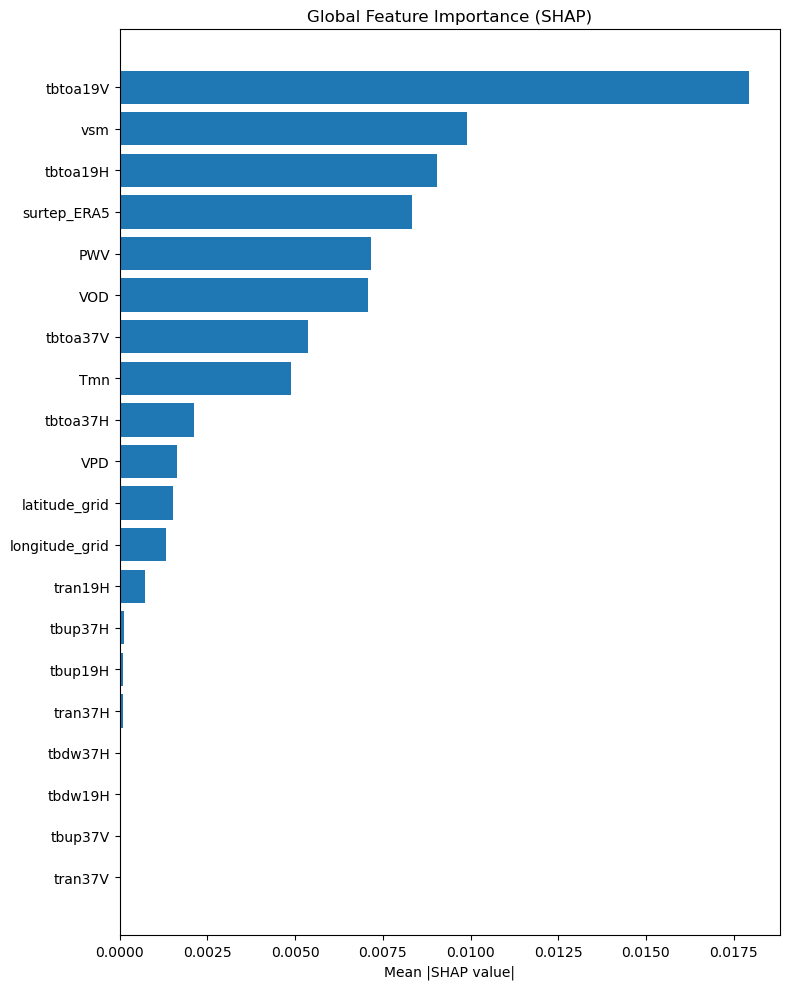

In [12]:
plt.figure(figsize=(8, 10))

plt.barh(
    importance_df["feature"][::-1],
    importance_df["importance"][::-1]
)

plt.xlabel("Mean |SHAP value|")
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

## Optimazation

Although the results we've obtained are a good first impresion of the accuracy of the models, these can be highly hindered by our choice of hyperparameters. We can fix this by optimizing said parameters, in hope of obtaining the true performance of every model.

In [56]:
# =====================================================
# Configuration
# =====================================================
RANDOM_STATE = 42
N_TRIALS = 100
EARLY_STOPPING_ROUNDS = 50

# Faster tuning CV
N_SPLITS_TUNING = 3

# Final evaluation CV
N_SPLITS_FINAL = 5

# Optional subsampling for tuning (set to 1.0 to disable)
TUNING_SAMPLE_FRAC = 0.7

# =====================================================
# Optional Data Subsampling for Tuning
# =====================================================
if TUNING_SAMPLE_FRAC < 1.0:
    X_tune = X18_train.sample(frac=TUNING_SAMPLE_FRAC, random_state=RANDOM_STATE)
    y_tune = y18_train.loc[X_tune.index]
else:
    X_tune = X18_train
    y_tune = y18_train

kf_tuning = KFold(
    n_splits=N_SPLITS_TUNING,
    shuffle=True,
    random_state=RANDOM_STATE
)

# =====================================================
# Objective Function
# =====================================================
def objective(trial):

    params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "tree_method": "hist",
        "device": "cuda",
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "min_child_weight": trial.suggest_float("min_child_weight", 0.1, 10, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 1e-6, 5.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-6, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "random_state": RANDOM_STATE,
    }

    rmse_scores = []

    for fold_idx, (train_idx, valid_idx) in enumerate(kf_tuning.split(X_tune)):

        X_train_fold = X_tune.iloc[train_idx]
        y_train_fold = y_tune.iloc[train_idx]
        X_valid_fold = X_tune.iloc[valid_idx]
        y_valid_fold = y_tune.iloc[valid_idx]

        dtrain = xgb.DMatrix(X_train_fold, label=y_train_fold)
        dvalid = xgb.DMatrix(X_valid_fold, label=y_valid_fold)

        model = xgb.train(
            params,
            dtrain,
            num_boost_round=2000,
            evals=[(dvalid, "valid")],
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            verbose_eval=False,
        )

        preds = model.predict(dvalid)
        rmse = root_mean_squared_error(y_valid_fold, preds)
        rmse_scores.append(rmse)

        # Report intermediate result for pruning
        trial.report(np.mean(rmse_scores), fold_idx)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(rmse_scores)

# =====================================================
# Study Setup
# =====================================================
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.SuccessiveHalvingPruner()
)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)

[I 2026-03-01 13:55:25,077] A new study created in memory with name: no-name-ed0d8a23-1fdc-4d12-8da9-dc6ca7042d3f


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-03-01 13:57:27,918] Trial 0 finished with value: 0.01917491542796294 and parameters: {'max_depth': 5, 'learning_rate': 0.17254716573280354, 'min_child_weight': 2.9106359131330697, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 1.1091814877139725e-05, 'reg_alpha': 2.231010801867921e-06, 'reg_lambda': 2.9154431891537547}. Best is trial 0 with value: 0.01917491542796294.
[I 2026-03-01 13:59:46,655] Trial 1 finished with value: 0.018852369859814644 and parameters: {'max_depth': 6, 'learning_rate': 0.08341106432362087, 'min_child_weight': 0.10994335574766201, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'gamma': 2.6451684446721577e-05, 'reg_alpha': 1.2329623163659841e-05, 'reg_lambda': 0.00541524411940254}. Best is trial 1 with value: 0.018852369859814644.
[I 2026-03-01 14:01:00,956] Trial 2 pruned. 
[I 2026-03-01 14:02:22,969] Trial 3 pruned. 
[I 2026-03-01 14:03:28,266] Trial 4 pruned. 
[I 2026-03-01 14:04:27,399] Tria

In [ ]:
best_params = study.best_params

final_params = {
    **best_params,
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "hist",
    "device": "cuda",
    "random_state": RANDOM_STATE,
}

kf_final = KFold(
    n_splits=N_SPLITS_FINAL,
    shuffle=True,
    random_state=RANDOM_STATE
)

final_rmse_scores = []

for train_idx, valid_idx in kf_final.split(X18_train):

    X_train_fold = X18_train.iloc[train_idx]
    y_train_fold = y18_train.iloc[train_idx]
    X_valid_fold = X18_train.iloc[valid_idx]
    y_valid_fold = y18_train.iloc[valid_idx]

    dtrain = xgb.DMatrix(X_train_fold, label=y_train_fold)
    dvalid = xgb.DMatrix(X_valid_fold, label=y_valid_fold)

    model = xgb.train(
        final_params,
        dtrain,
        num_boost_round=2000,
        evals=[(dvalid, "valid")],
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        verbose_eval=False,
    )

    preds = model.predict(dvalid)
    rmse = root_mean_squared_error(y_valid_fold, preds)
    final_rmse_scores.append(rmse)

print("Final 5-fold RMSE:", np.mean(final_rmse_scores))

print(final_params)

with open("best_xgb_params.json", "w") as f:
    json.dump(final_params, f, indent=4)

Final 5-fold RMSE: 0.01500487681478262


## Temporal and geographical focused training

Up until now, we've been spliting the dataset for training and testing in a random way. However, due to the nature of our subject (SWF) which is both temporaly dependent on previous and futures states and geographicaly dependent on its surroundings, we may be obtaining biased models that don't really understand the intrinsic relationship between the variables, but instead memorize most of teh true values of SWF and just return close geographical or temporal values.

In order to ensure this isn't the case, we'll retrain the models but with train/test splits based on temporal and geographical logic.

In [40]:
# Ensure day is sorted
unique_days = np.sort(df["day"].unique())

# Define split ratio
test_size = 0.27  # 27% for test
split_idx = int(len(unique_days) * (1 - test_size))

train_days = unique_days[:split_idx]
test_days = unique_days[split_idx:]

# Create indices
train_idx_time = df.index[df["day"].isin(train_days)]
test_idx_time  = df.index[df["day"].isin(test_days)]

print(f"Train samples: {len(train_idx_time)/len(df)*100:.2f}% ({len(train_idx_time)} samples)")
print(f"Test samples: {len(test_idx_time)/len(df)*100:.2f}% ({len(test_idx_time)} samples)")
print(f"Test proportion: {len(test_idx_time)/len(df):.3f}")

Train samples: 79.84% (10559971 samples)
Test samples: 20.16% (2665786 samples)
Test proportion: 0.202


In [41]:
# Desired test proportion
target_test_size = 0.19

# Quantile for rectangular corner selection
q = 1 - np.sqrt(target_test_size)

lat_cut = df["latitude_grid"].quantile(q)
lon_cut = df["longitude_grid"].quantile(q)

# Define spatial split
test_mask = (
    (df["latitude_grid"] >= lat_cut) &
    (df["longitude_grid"] >= lon_cut)
)

train_idx_geo = df.index[~test_mask]
test_idx_geo  = df.index[test_mask]

print(f"Train samples: {len(train_idx_geo)/len(df)*100:.2f}% ({len(train_idx_geo)} samples)")
print(f"Test samples: {len(test_idx_geo)/len(df)*100:.2f}% ({len(test_idx_geo)} samples)")
print(f"Test proportion: {len(test_idx_geo)/len(df):.3f}")

Train samples: 79.46% (10508577 samples)
Test samples: 20.54% (2717180 samples)
Test proportion: 0.205


In [47]:
# Create spatial blocks
lat_bins = np.linspace(df["latitude_grid"].min(), df["latitude_grid"].max(), 6)
lon_bins = np.linspace(df["longitude_grid"].min(), df["longitude_grid"].max(), 6)

df["lat_block"] = np.digitize(df["latitude_grid"], lat_bins)
df["lon_block"] = np.digitize(df["longitude_grid"], lon_bins)

# Combine into block id
df["geo_block"] = df["lat_block"].astype(str) + "_" + df["lon_block"].astype(str)

unique_blocks = df["geo_block"].unique()
np.random.seed(42)
np.random.shuffle(unique_blocks)

test_blocks = unique_blocks[:int(0.21 * len(unique_blocks))]

train_idx_geo = df.index[~df["geo_block"].isin(test_blocks)]
test_idx_geo  = df.index[df["geo_block"].isin(test_blocks)]

print(f"Train samples: {len(train_idx_geo)/len(df)*100:.2f}% ({len(train_idx_geo)} samples)")
print(f"Test samples: {len(test_idx_geo)/len(df)*100:.2f}% ({len(test_idx_geo)} samples)")
print(f"Test proportion: {len(test_idx_geo)/len(df):.3f}")

Train samples: 78.30% (10356088 samples)
Test samples: 21.70% (2869669 samples)
Test proportion: 0.217


In [48]:
# -------- TEMPORAL SET --------
X_temporal_train = df.loc[train_idx_time, features_18]
X_temporal_test  = df.loc[test_idx_time,  features_18]
y_temporal_train = y.loc[train_idx_time]
y_temporal_test  = y.loc[test_idx_time]

# -------- GEOGRAPHICAL SET --------
X_geo_train = df.loc[train_idx_geo, features_18]
X_geo_test  = df.loc[test_idx_geo,  features_18]
y_geo_train = y.loc[train_idx_geo]
y_geo_test  = y.loc[test_idx_geo]

In [49]:
results_temporal = train_and_evaluate_models_list(X_temporal_train, y_temporal_train, X_temporal_test, y_temporal_test, models)
results_geo = train_and_evaluate_models_list(X_geo_train, y_geo_train, X_geo_test, y_geo_test, models)

table_temporal = format_results_table(results_temporal)
table_geo = format_results_table(results_geo)

print(table_temporal)
print(table_geo)

                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.018645   0.000857  0.846524  0.019912  0.000889   
XGBoost            0.012796   0.000438  0.921519  0.013012  0.000468   

                   R²_test   Tiempo  
LinearRegression  0.815301   2.0484  
XGBoost           0.902787  14.7389  
                  MAE_train  MSE_train  R²_train  MAE_test  MSE_test  \
LinearRegression   0.018661   0.000849  0.848899  0.019840  0.000921   
XGBoost            0.012536   0.000416  0.925994  0.014214  0.000598   

                   R²_test   Tiempo  
LinearRegression  0.808017   2.0526  
XGBoost           0.875232  14.9712  
